# NNDL Coursework Part 2

In [10]:
import os
from google.colab import userdata

# Kaggle Authentication (To run it Kaggle API is needed)
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

# Dataset Download
!pip install kaggle>=1.8.0 -q
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset --unzip -p /content/brain-tumor/

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:10<00:00, 15.6MB/s]



In [11]:
%matplotlib inline
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path
from collections import Counter
import random
import time
import os
import copy
from google.colab import files

In [12]:
# Set the seed to allow reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using {device}')
print(f'Seed fixed at: {SEED}')

Using cuda
Seed fixed at: 42


In [13]:
# Data preparation and augmentation
IMG_SIZE = 224
BATCH_SIZE = 32

# Transforming the data to make it more suitable for training and testing to obtain higher accuracy.
# Transformation for training includes data augmentation techniques to help the model generalize better.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )])
# Transformation for testing only includes resizing and normalization to evaluate the model on original data.
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )])

# Labels for the folder names are glioma=0, meningioma=1, notumor=2, pituitary=3
TRAIN_PATH = '/content/brain-tumor/Training'
TEST_PATH  = '/content/brain-tumor/Testing'

train_dataset = torchvision.datasets.ImageFolder(
    root=TRAIN_PATH,
    transform=train_transform)

test_dataset = torchvision.datasets.ImageFolder(
    root=TEST_PATH,
    transform=test_transform)

# Print the dataset info to ensure the data is loaded correctly and understand the distribution.
CLASS_NAMES = train_dataset.classes
print(f"Classes found: {CLASS_NAMES}")
print(f"Training images: {len(train_dataset):,}")
print(f"Testing images: {len(test_dataset):,}")

train_counts = Counter(train_dataset.targets)
test_counts  = Counter(test_dataset.targets)
print("Train class counts:",
      {CLASS_NAMES[k]: v for k, v in sorted(train_counts.items())})
print("Test  class counts:",
      {CLASS_NAMES[k]: v for k, v in sorted(test_counts.items())})

# Load the dataset for test and training
train_loader = DataLoader(train_dataset,
                          batch_size = BATCH_SIZE,
                          shuffle = True,
                          num_workers = 2,
                          pin_memory = True)

test_loader = DataLoader(test_dataset,
                         batch_size = BATCH_SIZE,
                         shuffle = False,
                         num_workers = 2,
                         pin_memory = True)

print(f"Training batches: {len(train_loader)}")
print(f"Testing batches:  {len(test_loader)}")

Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']
Training images: 5,600
Testing images: 1,600
Train class counts: {'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400}
Test  class counts: {'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}
Training batches: 175
Testing batches:  50


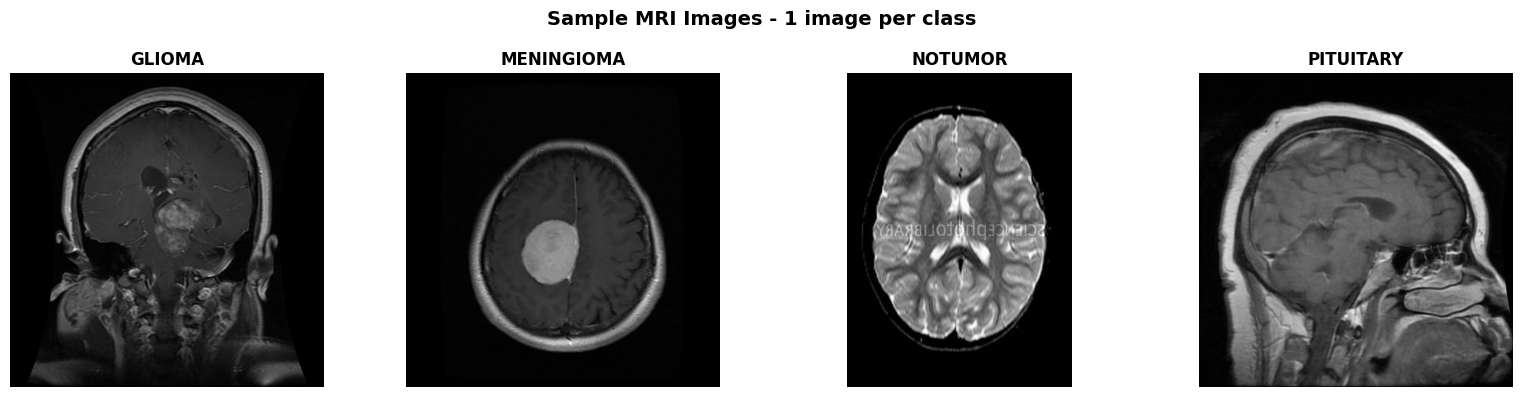

In [14]:
# Visualize one sample image from each class to ensure the dataset load correctly
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Sample MRI Images - 1 image per class',fontsize=14,fontweight='bold')
for idx, class_name in enumerate(CLASS_NAMES):

    class_path = Path(TRAIN_PATH) / class_name
    img_path = list(class_path.glob('*.jpg'))[0]

    img = plt.imread(str(img_path))
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f'{class_name.upper()}',fontweight='bold',fontsize=12)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png',dpi=150, bbox_inches='tight')
plt.show()

## CNN

In [15]:
# A CNN architecture with 4 convolutional blocks
# This will learn features without any pretrained weights
class CNN_Model(nn.Module):
    def __init__(self, num_classes=4):
        super(CNN_Model, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3,padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3,padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3,padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3,padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        #  # The dropout layer is used to reduce overfitting and generalize the model
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

cnn_model = CNN_Model(num_classes=4).to(device)
total_params = sum(p.numel()
                   for p in cnn_model.parameters()
                   if p.requires_grad)

print(f"Total parameters: {total_params:,}")

Total parameters: 422,564


## ResNet50 Pretrained

Used two strategies here: **frozen**, which locks all the pretrained layers and trains only the final layer; and **fine-tuned**, which unlocks all layers and trains the entire network.

In [16]:
# A ResNet50 model is build with 2 strategies: freezing or fine-tuning the pretrained layers.
# A custom classifier is used to deal with the 4-class classification task of the dataset
def build_resnet50(strategy='finetune', num_classes=4):

    model = models.resnet50(weights='IMAGENET1K_V1')

    if strategy == 'frozen':
        for param in model.parameters():
            param.requires_grad = False
        print("Frozen")

    elif strategy == 'finetune':
        for param in model.parameters():
            param.requires_grad = True
        print("Fine-tuned")

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )

    return model.to(device)

resnet_frozen = build_resnet50(strategy='frozen')
frozen_params = sum(p.numel() for p in resnet_frozen.parameters()
                    if p.requires_grad)
print(f"Parameters: {frozen_params:,}")

resnet_finetune = build_resnet50(strategy='finetune')
finetune_params = sum(p.numel() for p in resnet_finetune.parameters()
                      if p.requires_grad)
print(f"Parameters: {finetune_params:,}")

Frozen
Parameters: 526,084
Fine-tuned
Parameters: 24,034,116


In [17]:
# This training function that handles both CNN and ResNet50 models.
# Cross-entropy loss, Adam optimizer, and a learning rate scheduler is used to reduce the learning rate if the test accuracy not increase.
def train_model(model, train_loader, test_loader,
                num_epochs=20, lr=0.0001,
                model_name='Model',
                save_path=None):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad,
               model.parameters()),
        lr=lr,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=3,
    )

    # Track loss, accuracy in both training and testing runs.
    batch_losses = []
    train_accuracy = []
    test_accuracy = []
    test_losses = []
    # Best model weight is saved based on test accuracy
    best_accuracy = 0.0
    best_state = None

    print(f"Training: {model_name}")
    print(f"Epochs: {num_epochs}  LR: {lr}")

    # The training loop iterates through the assigned number of epochs, performing training and evaluation in each epoch.
    for epoch in range(num_epochs):
        start_time = time.time()

        model.train()
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.detach().item())
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_acc = 100 * correct_train / total_train
        train_accuracy.append(train_acc)

        model.eval()
        correct_test = 0
        total_test = 0
        test_loss_sum = 0.0

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss_sum += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                correct_test += (predicted == labels).sum().item()
                total_test += labels.size(0)

        test_acc = 100 * correct_test / total_test
        test_loss = test_loss_sum / total_test
        test_accuracy.append(test_acc)
        test_losses.append(test_loss)

        scheduler.step(test_acc)

        new_best = test_acc > best_accuracy

        #Update and save the model state if current test accuracy is the best
        if new_best:
            best_accuracy = test_acc
            best_state = copy.deepcopy(model.state_dict())

        # Record the time taken for each epoch to run
        epoch_time = time.time() - start_time

        print(f"Epoch {epoch+1:>2}/{num_epochs}  "
              f"Loss: {batch_losses[-1]:.4f}  "
              f"TestLoss: {test_loss:.4f} "
              f"Train: {train_acc:.2f}% "
              f"Test: {test_acc:.2f}%  "
              f"Time: {epoch_time:.1f}s  "
              f"{'new best' if new_best else ''}")

    if best_state is not None:
        model.load_state_dict(best_state)
        if save_path is not None:
            torch.save(best_state, save_path)
            print(f"Best weights saved to {save_path}")

    print(f"Best Test Accuracy: {best_accuracy:.2f}%")

    return batch_losses, train_accuracy, test_accuracy,test_losses, best_accuracy

## Experiment 1
#### What this experiment does answer the question:
##### "Does transfer learning from ImageNet help classify brain tumours better than learning from scratch?"
We train two models:\
CNN — no prior knowledge\
ResNet50 Fine-tuned — pretrained on ImageNet




In [18]:
# Experiment 1 compares the performance of a CNN trained from scratch against a ResNet50 model that is fine-tuned from pretrained ImageNet weights.
print("Experiment 1: CNN vs ResNet50 Fine-tuned")

cnn_model = CNN_Model(num_classes=4).to(device)
cnn_losses, cnn_train_accs, cnn_test_accs, cnn_test_losses, cnn_best = train_model(
    cnn_model,
    train_loader,
    test_loader,
    num_epochs = 20,
    lr = 0.001,
    model_name = 'CNN',
    save_path  = 'CNN_best.pth')

resnet_finetune = build_resnet50(strategy='finetune')

res_losses, res_train_accs, res_test_accs, res_test_losses, res_best = train_model(
    resnet_finetune,
    train_loader,
    test_loader,
    num_epochs = 20,
    lr = 0.0001,
    model_name = 'ResNet50 Fine-tuned',
    save_path  = 'ResNet50_finetuned_best.pth')

print("Experiment 1 Results")
print(f"CNN:{cnn_best:.2f}%")
print(f"ResNet50 Fine-tuned:{res_best:.2f}%")
print(f"Improvement:{res_best - cnn_best:.2f}%")

# Save the weights
files.download('CNN_best.pth')
files.download('ResNet50_finetuned_best.pth')

Experiment 1: CNN vs ResNet50 Fine-tuned
Training: CNN
Epochs: 20  LR: 0.001
Epoch  1/20  Loss: 1.2153  TestLoss: 1.2162 Train: 67.84% Test: 54.19%  Time: 20.5s  new best
Epoch  2/20  Loss: 0.4886  TestLoss: 1.1208 Train: 76.48% Test: 61.88%  Time: 20.4s  new best
Epoch  3/20  Loss: 0.3232  TestLoss: 1.5162 Train: 80.05% Test: 52.31%  Time: 20.4s  
Epoch  4/20  Loss: 0.5513  TestLoss: 0.9692 Train: 82.02% Test: 67.25%  Time: 20.7s  new best
Epoch  5/20  Loss: 0.3449  TestLoss: 1.0572 Train: 83.64% Test: 63.19%  Time: 20.8s  
Epoch  6/20  Loss: 0.7806  TestLoss: 1.5827 Train: 84.68% Test: 55.75%  Time: 20.3s  
Epoch  7/20  Loss: 0.2394  TestLoss: 1.2782 Train: 85.57% Test: 63.12%  Time: 20.5s  
Epoch  8/20  Loss: 0.5853  TestLoss: 0.7921 Train: 86.48% Test: 72.38%  Time: 20.4s  new best
Epoch  9/20  Loss: 0.5695  TestLoss: 1.9064 Train: 87.41% Test: 54.12%  Time: 20.5s  
Epoch 10/20  Loss: 0.2042  TestLoss: 0.9463 Train: 87.27% Test: 71.56%  Time: 20.3s  
Epoch 11/20  Loss: 0.1794  Test

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

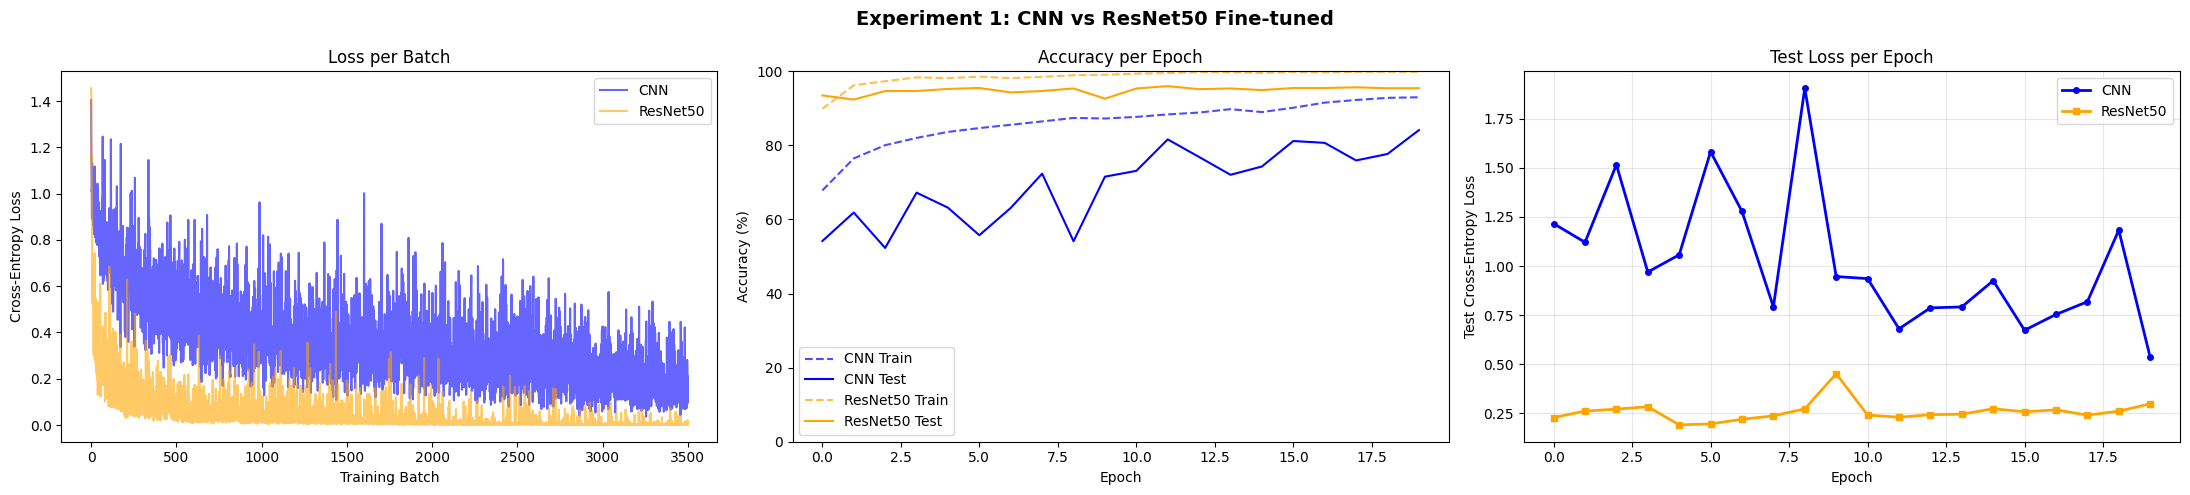

In [19]:
# Experiment 1 visualization
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.suptitle('Experiment 1: CNN vs ResNet50 Fine-tuned',fontsize=14, fontweight='bold')

# Plot 1 Loss per batch
axes[0].plot(cnn_losses,
             alpha=0.6,
             label='CNN',
             color='blue')
axes[0].plot(res_losses,
             alpha=0.6,
             label='ResNet50',
             color='orange')
axes[0].set_xlabel('Training Batch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Loss per Batch')
axes[0].legend()

# Plot 2 Accuracy per epoch
axes[1].plot(cnn_train_accs,
             label='CNN Train',
             color='blue',
             linestyle='--',
             alpha=0.7)
axes[1].plot(cnn_test_accs,
             label='CNN Test',
             color='blue')
axes[1].plot(res_train_accs,
             label='ResNet50 Train',
             color='orange',
             linestyle='--',
             alpha=0.7)
axes[1].plot(res_test_accs,
             label='ResNet50 Test',
             color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy per Epoch')
axes[1].legend()
axes[1].set_ylim(0, 100)

# Plot 3 Test loss per epoch
axes[2].plot(cnn_test_losses,
             label='CNN',
             color='blue',
             linewidth=2,
             marker='o',
             markersize=4)
axes[2].plot(res_test_losses,
             label='ResNet50',
             color='orange',
             linewidth=2,
             marker='s',
             markersize=4)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Test Cross-Entropy Loss')
axes[2].set_title('Test Loss per Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment1_results.png',dpi=150, bbox_inches='tight')
plt.show()

## Experiment 2
#### Question: "Is it better to freeze ResNet50 layers or fine-tune the entire network?"


In [20]:
# Experiment 2 is a comparison between two training strategies for ResNet50
print("Experiment 2: Frozen vs Fine-tuned ResNet50")

resnet_frozen = build_resnet50(strategy='frozen')

frz_losses, frz_train_accs, frz_test_accs, frz_test_losses, frz_best = train_model(
    resnet_frozen,
    train_loader,
    test_loader,
    num_epochs=20,
    lr=0.001,
    model_name='ResNet50 Frozen',
    save_path='ResNet50_frozen_best.pth')

print("Experiment 2 result")
print(f"ResNet50 Frozen: {frz_best:.2f}%")
print(f"ResNet50 Fine-tuned: {res_best:.2f}%")
print(f"Fine-tuning gain: {res_best - frz_best:.2f}%")
files.download('ResNet50_frozen_best.pth')

Experiment 2: Frozen vs Fine-tuned ResNet50
Frozen
Training: ResNet50 Frozen
Epochs: 20  LR: 0.001
Epoch  1/20  Loss: 0.3816  TestLoss: 0.6643 Train: 83.27% Test: 77.62%  Time: 20.8s  new best
Epoch  2/20  Loss: 0.1666  TestLoss: 0.5203 Train: 87.43% Test: 83.75%  Time: 21.1s  new best
Epoch  3/20  Loss: 0.3957  TestLoss: 0.5123 Train: 89.11% Test: 84.69%  Time: 21.3s  new best
Epoch  4/20  Loss: 0.3542  TestLoss: 0.5058 Train: 89.73% Test: 85.62%  Time: 20.8s  new best
Epoch  5/20  Loss: 0.4285  TestLoss: 0.5349 Train: 90.36% Test: 85.00%  Time: 20.6s  
Epoch  6/20  Loss: 0.4803  TestLoss: 0.4652 Train: 90.70% Test: 87.31%  Time: 20.7s  new best
Epoch  7/20  Loss: 0.2491  TestLoss: 0.4258 Train: 90.71% Test: 87.38%  Time: 20.6s  new best
Epoch  8/20  Loss: 0.1855  TestLoss: 0.5546 Train: 91.71% Test: 85.56%  Time: 20.7s  
Epoch  9/20  Loss: 0.1678  TestLoss: 0.6162 Train: 91.70% Test: 85.94%  Time: 20.5s  
Epoch 10/20  Loss: 0.2781  TestLoss: 0.4500 Train: 91.79% Test: 88.56%  Time: 2

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

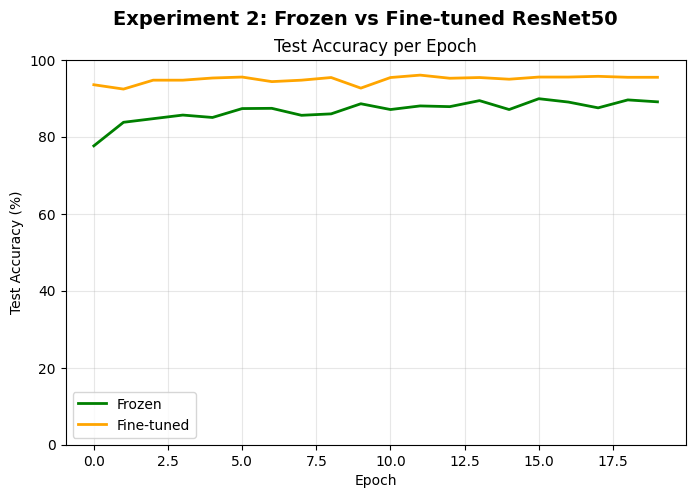

In [21]:
# Experiment 2 visualization
fig,axes = plt.subplots(figsize=(8, 5))
fig.suptitle('Experiment 2: Frozen vs Fine-tuned ResNet50',fontsize=14, fontweight='bold')

# PLOT 1 Accuracy per epoch
axes.plot(frz_test_accs, label='Frozen',
             color='green', linewidth=2)
axes.plot(res_test_accs, label='Fine-tuned',
             color='orange', linewidth=2)
axes.set_xlabel('Epoch')
axes.set_ylabel('Test Accuracy (%)')
axes.set_title('Test Accuracy per Epoch')
axes.legend()
axes.set_ylim(0, 100)
axes.grid(True, alpha=0.3)

plt.show()

# Experiment 3
#### Question: "How does limited training data affect CNN vs ResNet50?"



In [24]:
# Experiment 3 investigates the impact of training data scarcity on the performance of both CNN and ResNet50 models.
print("Experiment 3: Data Scarcity Study")
fractions   = [0.25, 0.50, 0.75, 1.0]
cnn_results = []
res_results = []

# A subset of the training dataset is created for each fraction of the training data
for frac in fractions:
    n = int(len(train_dataset) * frac)
    remainder = len(train_dataset) - n

    subset, _ = random_split(
        train_dataset,
        [n, remainder],
        generator=torch.Generator().manual_seed(SEED)
    )

    # DataLoader for the subset to train the models
    subset_loader = DataLoader(
        subset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2
    )

    # Save the model
    cnn_save = f'CNN_data{int(frac*100)}.pth'
    res_save = f'ResNet50_data{int(frac*100)}.pth'

    # Show the number of images used for training in each fraction.
    print(f"Using {int(frac*100)}% of data = {n} images")

    m1 = CNN_Model(num_classes=4).to(device)
    _, _, _, _,best_cnn = train_model(
        m1,
        subset_loader,
        test_loader,
        num_epochs=15,
        lr=0.001,
        model_name=f'CNN {int(frac*100)}%',
        save_path=cnn_save
    )
    cnn_results.append(best_cnn)

    m2 = build_resnet50(strategy='finetune')
    _, _, _, _,best_res = train_model(
        m2,
        subset_loader,
        test_loader,
        num_epochs=15,
        lr=0.0001,
        model_name=f'ResNet50 {int(frac*100)}%',
        save_path=res_save
    )
    res_results.append(best_res)

    # Download the models
    files.download(cnn_save)
    files.download(res_save)

print("Experiment 3 Results")
print(f"{'Data %':<10} {'CNN':>12} {'ResNet50':>12}")
for frac, cnn_acc, res_acc in zip(fractions, cnn_results, res_results):
    print(f"{int(frac*100)}%{'':<7}"
          f"{cnn_acc:>11.2f}%"
          f"{res_acc:>11.2f}%")

Experiment 3: Data Scarcity Study
Using 25% of data = 1400 images
Training: CNN 25%
Epochs: 15  LR: 0.001
Epoch  1/15  Loss: 1.2734  TestLoss: 1.1679 Train: 60.57% Test: 53.12%  Time: 7.8s  new best
Epoch  2/15  Loss: 0.9576  TestLoss: 1.8179 Train: 68.57% Test: 48.12%  Time: 7.9s  
Epoch  3/15  Loss: 0.4254  TestLoss: 1.4948 Train: 71.07% Test: 45.50%  Time: 7.8s  
Epoch  4/15  Loss: 0.6022  TestLoss: 0.8799 Train: 71.50% Test: 66.38%  Time: 7.9s  new best
Epoch  5/15  Loss: 0.5436  TestLoss: 1.0385 Train: 76.21% Test: 60.12%  Time: 7.9s  
Epoch  6/15  Loss: 0.3283  TestLoss: 1.4260 Train: 77.86% Test: 49.19%  Time: 7.9s  
Epoch  7/15  Loss: 0.4818  TestLoss: 1.3113 Train: 79.71% Test: 53.88%  Time: 7.8s  
Epoch  8/15  Loss: 0.5384  TestLoss: 0.9840 Train: 81.57% Test: 68.06%  Time: 7.9s  new best
Epoch  9/15  Loss: 0.5993  TestLoss: 0.8290 Train: 80.71% Test: 67.44%  Time: 8.0s  
Epoch 10/15  Loss: 0.4349  TestLoss: 0.8193 Train: 82.21% Test: 74.00%  Time: 8.0s  new best
Epoch 11/15 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Experiment 3 Results
Data %              CNN     ResNet50
25%             76.00%      92.81%
50%             81.44%      95.19%
75%             84.38%      95.25%
100%             85.38%      95.81%


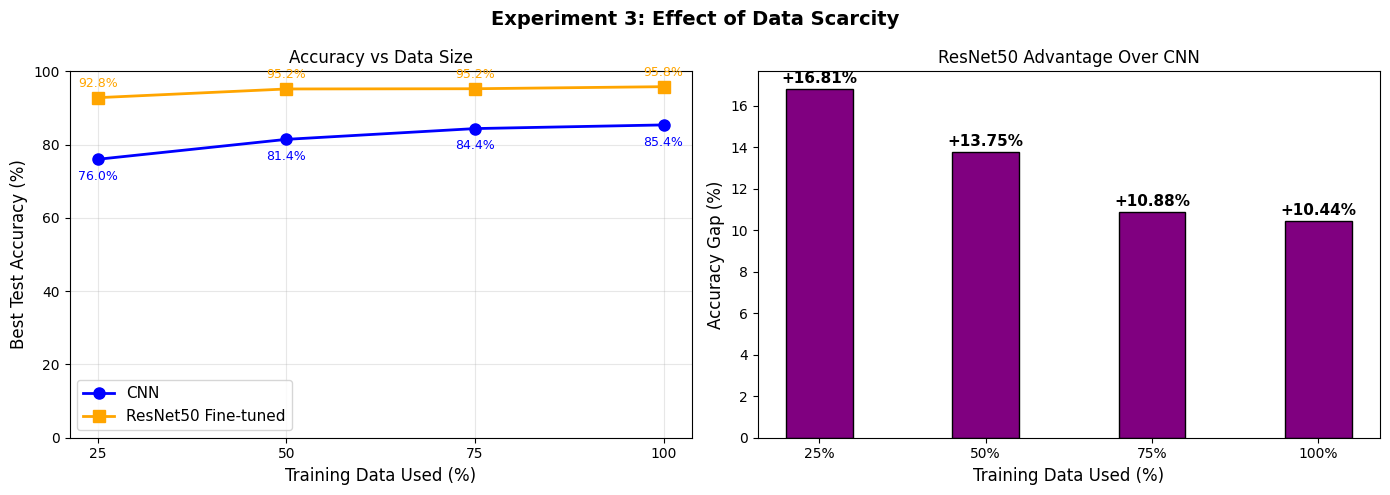

In [25]:
# Experiment 3 visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Experiment 3: Effect of Data Scarcity',fontsize=14, fontweight='bold')

x = [25, 50, 75, 100]

# Plot 1 Accuracy vs data percentage
axes[0].plot(x,cnn_results,'o-',
             color='blue',
             label='CNN',
             linewidth=2, markersize=8)
axes[0].plot(x,res_results,'s-',
             color='orange',
             label='ResNet50 Fine-tuned',
             linewidth=2, markersize=8)

for i, (c, r) in enumerate(
        zip(cnn_results, res_results)):
      axes[0].annotate(
        f'{c:.1f}%',
        (x[i], c),
        textcoords='offset points',
        xytext=(0, -15),
        ha='center', fontsize=9, color='blue')
      axes[0].annotate(
        f'{r:.1f}%',
        (x[i], r),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center', fontsize=9, color='orange')

axes[0].set_xlabel('Training Data Used (%)',fontsize=12)
axes[0].set_ylabel('Best Test Accuracy (%)',fontsize=12)
axes[0].set_title('Accuracy vs Data Size')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(x)
axes[0].set_ylim(0, 100)

# Plot 2 Gap between models
gaps = [r - c for r, c in zip(res_results, cnn_results)]
bars = axes[1].bar([f'{int(f*100)}%' for f in fractions],
                   gaps,
                   color='purple',
                   edgecolor='black',
                   width=0.4)
axes[1].set_xlabel('Training Data Used (%)',fontsize=12)
axes[1].set_ylabel('Accuracy Gap (%)',fontsize=12)
axes[1].set_title('ResNet50 Advantage Over CNN')
for bar, gap in zip(bars, gaps):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'+{gap:.2f}%',
                 ha='center',
                 fontweight='bold',
                 fontsize=11)

plt.tight_layout()
plt.savefig('experiment3_scarcity.png',dpi=150, bbox_inches='tight')
plt.show()

## Experiment 4
#### Question: "Which tumor type is hardest to classify and why?"


In [26]:
# Experiment 4 aim to identify which tumor types is the hardest for the ResNet50 Model
print("Experiment 4: Error Analysis")

resnet_finetune.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = resnet_finetune(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

Experiment 4: Error Analysis


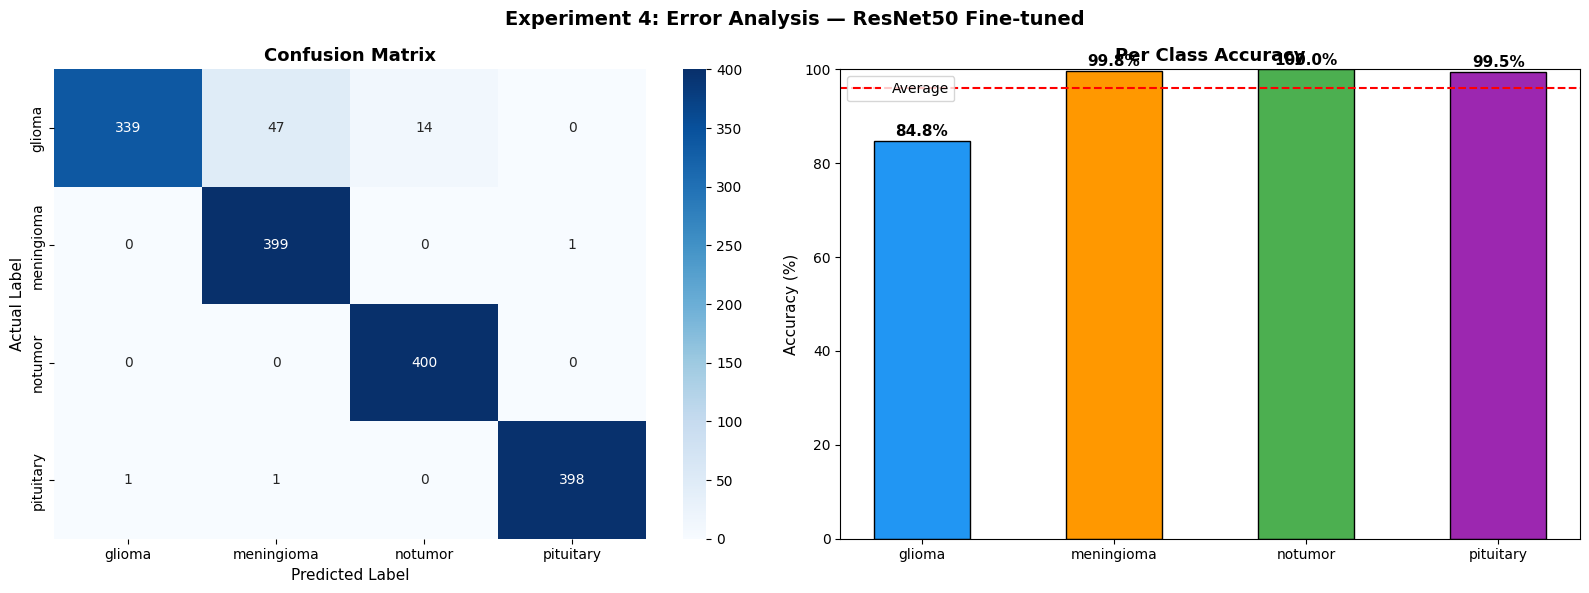

Detailed Classification Report:
              precision    recall  f1-score   support

      glioma       1.00      0.85      0.92       400
  meningioma       0.89      1.00      0.94       400
     notumor       0.97      1.00      0.98       400
   pituitary       1.00      0.99      1.00       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600



In [27]:
# Experiment 4 visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Experiment 4: Error Analysis — ResNet50 Fine-tuned',fontsize=14, fontweight='bold')

# Plot 1 Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=axes[0],
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
axes[0].set_title('Confusion Matrix',fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# Plot 2  Per Class Accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']
bars = axes[1].bar(CLASS_NAMES,
                   per_class_acc,
                   color=colors,
                   edgecolor='black',
                   width=0.5)

axes[1].set_ylabel('Accuracy (%)', fontsize=11)
axes[1].set_title('Per Class Accuracy',fontsize=13,fontweight='bold')
axes[1].set_ylim(0,100)
axes[1].axhline(y = sum(per_class_acc) / len(per_class_acc),
                color ='red',
                linestyle = '--',
                linewidth = 1.5,
                label = 'Average')
axes[1].legend()

for bar, acc in zip(bars, per_class_acc):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{acc:.1f}%',
                 ha = 'center',
                 fontweight = 'bold',
                 fontsize = 11)

plt.tight_layout()
plt.savefig('Experiment4_confusion.png',dpi = 150, bbox_inches = 'tight')
plt.show()

print("Detailed Classification Report:")
print(classification_report(y_true, y_pred,target_names=CLASS_NAMES))

## Result

In [28]:
print("Result Summary")

print("Experiment 1 — Transfer Learning")
print(f"CNN:{cnn_best:.2f}%")
print(f"ResNet50 Fine-tuned:{res_best:.2f}%")
print(f"Transfer learning gain:{res_best-cnn_best:.2f}%")

print("Experiment 2 — Training Strategy")
print(f"ResNet50 Frozen: {frz_best:.2f}%")
print(f"ResNet50 Fine-tuned:{res_best:.2f}%")
print(f"  Fine-tuning gain:{res_best-frz_best:.2f}%")

print("Experiment 3 — Data Scarcity")
print(f" {'Data':<8} {'CNN':>10} {'ResNet50':>10}")
for frac, c, r in zip(fractions,cnn_results,res_results):
    print(f"{int(frac*100)}%{'':<5}"
          f"{c:>9.2f}% {r:>9.2f}%")

print("Experiment 4 — Per Class Accuracy")
for name, acc in zip(CLASS_NAMES, per_class_acc):
    print(f"{name:<15} {acc:.1f}%")

all_models = {
    'CNN': cnn_best,
    'ResNet50 Frozen': frz_best,
    'ResNet50 Fine-tuned': res_best,
}
best_name, best_value = max(all_models.items(), key=lambda kv: kv[1])

Result Summary
Experiment 1 — Transfer Learning
CNN:84.12%
ResNet50 Fine-tuned:96.00%
Transfer learning gain:11.88%
Experiment 2 — Training Strategy
ResNet50 Frozen: 89.88%
ResNet50 Fine-tuned:96.00%
  Fine-tuning gain:6.12%
Experiment 3 — Data Scarcity
 Data            CNN   ResNet50
25%         76.00%     92.81%
50%         81.44%     95.19%
75%         84.38%     95.25%
100%         85.38%     95.81%
Experiment 4 — Per Class Accuracy
glioma          84.8%
meningioma      99.8%
notumor         100.0%
pituitary       99.5%
